## ANN Assignment 2
syeda rija ali
23K-0057

In [34]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [35]:
# dataset gen
def lhs_sample(n, lo, hi, d=4, seed=0):
    sampler = qmc.LatinHypercube(d=d, seed=seed)
    raw = sampler.random(n=n)
    return qmc.scale(raw, [lo]*d, [hi]*d)


def make_dataset1(n_train=500, n_test=5000):
    #Eq. 12: f = exp(-0.5x) + log(1+exp(0.4y)) + tanh(t) + sin(z) - 0.4
    def f(X):
        x, y, t, z = X[:,0], X[:,1], X[:,2], X[:,3]
        return np.exp(-0.5*x) + np.log1p(np.exp(0.4*y)) + np.tanh(t) + np.sin(z) - 0.4

    X_train = lhs_sample(n_train, lo=0, hi=4, seed=0)
    X_test  = lhs_sample(n_test,  lo=0, hi=6, seed=1)   # extrapolation up to 6
    return X_train, f(X_train), X_test, f(X_test), f


def make_dataset2(n_train=500, n_test=5000):
    #Eq. 13-14: g = exp(-0.3x) * (0.15y)^2 * tanh(0.3t) * (0.2*sin(0.5z+2)+0.5)
    def g(X):
        x, y, t, z = X[:,0], X[:,1], X[:,2], X[:,3]
        fx = np.exp(-0.3*x)
        fy = (0.15*y)**2
        ft = np.tanh(0.3*t)
        fz = 0.2*np.sin(0.5*z + 2) + 0.5
        return fx * fy * ft * fz

    X_train = lhs_sample(n_train, lo=0, hi=4,  seed=2)
    X_test  = lhs_sample(n_test,  lo=0, hi=10, seed=3)  # extrapolation up to 10
    return X_train, g(X_train), X_test, g(X_test), g


X1_tr, y1_tr, X1_te, y1_te, fn1 = make_dataset1()
X2_tr, y2_tr, X2_te, y2_te, fn2 = make_dataset2()

print("Dataset 1 — Train:", X1_tr.shape, "| Test:", X1_te.shape)
print("Dataset 2 — Train:", X2_tr.shape, "| Test:", X2_te.shape)


Dataset 1 — Train: (500, 4) | Test: (5000, 4)
Dataset 2 — Train: (500, 4) | Test: (5000, 4)


In [36]:
#  PYTORCH
class PosLinear(nn.Module):

    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.log_w = nn.Parameter(torch.empty(out_features, in_features))
        self.b     = nn.Parameter(torch.zeros(out_features)) if bias else None
        nn.init.normal_(self.log_w, mean=-1.0, std=0.3)   # small init → softplus ~ small positive

    @property
    def weight(self):
        return F.softplus(self.log_w)   # always >= 0

    def forward(self, x):
        out = x @ self.weight.T
        return (out + self.b) if self.b is not None else out


def sp(x):  return F.softplus(x)     # sigma_mc
def sig(x): return torch.sigmoid(x)  # sigma_m = sigma_a

print("PosLinear defined. softplus(0) =", round(float(sp(torch.tensor(0.0))), 4))

PosLinear defined. softplus(0) = 0.6931


In [37]:
# feed forward

class FFNN(nn.Module):


    def __init__(self, n_hidden=2, n_neurons=30):
        super().__init__()
        layers = [nn.Linear(4, n_neurons), nn.Tanh()]
        for _ in range(n_hidden - 1):
            layers += [nn.Linear(n_neurons, n_neurons), nn.Tanh()]
        layers.append(nn.Linear(n_neurons, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, X):
        return self.net(X)

# Quick param count
m = FFNN()
print("FFNN trainable params:", sum(p.numel() for p in m.parameters()))

FFNN trainable params: 1111


In [48]:
import torch.nn.functional as F

#  ISNN-1 — PyTorch

class ISNN1_PyTorch(nn.Module):
    def __init__(self, d=1, nl=2, nh=10):
        super().__init__()
        self.nl = nl
        self.y_layers = nn.ModuleList(
            [PosLinear(d if i == 0 else nh, nh) for i in range(nl)]
        )
        self.z_layers = nn.ModuleList(
            [nn.Linear(d if i == 0 else nh, nh) for i in range(nl)]
        )
        self.t_layers = nn.ModuleList(
            [PosLinear(d if i == 0 else nh, nh) for i in range(nl)]
        )
        self.W0_xx = nn.Linear(d, nh, bias=True)       # free
        self.W_xy  = PosLinear(nh, nh, bias=False)     # nonneg (y->x coupling)
        self.W_xz  = nn.Linear(nh, nh, bias=False)     # free   (z->x coupling)
        self.W_xt  = PosLinear(nh, nh, bias=False)     # nonneg (t->x coupling)
        self.x_layers = nn.ModuleList(
            [PosLinear(nh, nh) for _ in range(nl - 1)]
        )

        self.out = nn.Linear(nh, 1)

    def forward(self, X):
        x0 = X[:, 0:1]
        y0 = X[:, 1:2]
        t0 = X[:, 2:3]
        z0 = X[:, 3:4]

        # y branch (Eq. 1)
        yh = y0
        for layer in self.y_layers:
            yh = sp(layer(yh))

        # z branch (Eq. 2)
        zh = z0
        for layer in self.z_layers:
            zh = sig(layer(zh))

        # t branch (Eq. 3)
        th = t0
        for layer in self.t_layers:
            th = sig(layer(th))

        # x layer 0 (Eq. 4): combining all branches
        F0 = self.W0_xx(x0) + self.W_xy(yh) + self.W_xz(zh) + self.W_xt(th)
        xh = sp(F0)

        # x layers 1->nl-1 (Eq. 5)
        for layer in self.x_layers:
            xh = sp(layer(xh))

        return self.out(xh)

m1 = ISNN1_PyTorch()
print("ISNN-1 (PyTorch) trainable params:", sum(p.numel() for p in m1.parameters()))

ISNN-1 (PyTorch) trainable params: 831


In [49]:
#  ISNN-2 — PyTorch
class ISNN2_PyTorch(nn.Module):
    def __init__(self, d=1, H=2, nh=15):
        super().__init__()
        self.H  = H
        nb = H - 1   # number of hidden layers in side branches
        self.nb = nb
        self.y_layers = nn.ModuleList(
            [PosLinear(d if i == 0 else nh, nh) for i in range(nb)]
        )
        self.z_layers = nn.ModuleList(
            [nn.Linear(d if i == 0 else nh, nh) for i in range(nb)]
        )
        self.t_layers = nn.ModuleList(
            [PosLinear(d if i == 0 else nh, nh) for i in range(nb)]
        )
        self.x0_Wxx = nn.Linear(d, nh, bias=False)     # free
        self.x0_Wxy = PosLinear(d, nh, bias=False)     # nonneg
        self.x0_Wxz = nn.Linear(d, nh, bias=False)     # free
        self.x0_Wxt = PosLinear(d, nh, bias=False)     # nonneg
        self.x0_b   = nn.Parameter(torch.zeros(nh))
        self.Wxx  = nn.ModuleList([PosLinear(nh, nh, bias=False) for _ in range(nb)])  # nonneg
        self.Wxx0 = nn.ModuleList([nn.Linear(d, nh, bias=False)  for _ in range(nb)])  # skip, free
        self.Wxy  = nn.ModuleList([PosLinear(nh, nh, bias=False) for _ in range(nb)])  # nonneg
        self.Wxz  = nn.ModuleList([nn.Linear(nh, nh, bias=False) for _ in range(nb)])  # free
        self.Wxt  = nn.ModuleList([PosLinear(nh, nh, bias=False) for _ in range(nb)])  # nonneg
        self.bx   = nn.ParameterList([nn.Parameter(torch.zeros(nh)) for _ in range(nb)])

        self.out = nn.Linear(nh, 1)

    def forward(self, X):
        x0 = X[:, 0:1]
        y0 = X[:, 1:2]
        t0 = X[:, 2:3]
        z0 = X[:, 3:4]

        # y branch (Eq. 6)
        yh = y0
        for layer in self.y_layers:
            yh = sp(layer(yh))

        # z branch (Eq. 7)
        zh = z0
        for layer in self.z_layers:
            zh = sig(layer(zh))

        # t branch (Eq. 8)
        th = t0
        for layer in self.t_layers:
            th = sig(layer(th))

        # x layer 0 (Eq. 9): combining raw inputs
        xh = sp(
            self.x0_Wxx(x0) + self.x0_Wxy(y0) +
            self.x0_Wxz(z0) + self.x0_Wxt(t0) + self.x0_b
        )

        # x layers 1..H-1 (Eq. 10): skip from x0 at each layer
        for Wxx, Wxx0, Wxy, Wxz, Wxt, b in zip(
            self.Wxx, self.Wxx0, self.Wxy, self.Wxz, self.Wxt, self.bx
        ):
            xh = sp(
                Wxx(xh) + Wxx0(x0) + Wxy(yh) + Wxz(zh) + Wxt(th) + b
            )

        return self.out(xh)


m2 = ISNN2_PyTorch()
print("ISNN-2 (PyTorch) trainable params:", sum(p.numel() for p in m2.parameters()))

ISNN-2 (PyTorch) trainable params: 1111


In [40]:
#  PYTORCH TRAINING LOOP


def train_pytorch(model, X_tr, y_tr, X_te, y_te,
                  epochs=3000, lr=1e-3, print_every=500):

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    Xtr_t = torch.tensor(X_tr, dtype=torch.float32)
    ytr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
    Xte_t = torch.tensor(X_te, dtype=torch.float32)
    yte_t = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)

    train_losses, test_losses = [], []

    for epoch in range(1, epochs + 1):
        #Forward + Backward
        model.train()
        optimizer.zero_grad()
        pred = model(Xtr_t)
        loss = criterion(pred, ytr_t)
        loss.backward()
        optimizer.step()

       #evaluatibg
        model.eval()
        with torch.no_grad():
            test_loss = criterion(model(Xte_t), yte_t).item()

        train_losses.append(loss.item())
        test_losses.append(test_loss)

        if epoch % print_every == 0 or epoch == 1:
            print(f"  Epoch {epoch:>5d} | Train MSE: {loss.item():.4e} | Test MSE: {test_loss:.4e}")

    return np.array(train_losses), np.array(test_losses)


def pt_predict(model, X):
    """Run inference — returns numpy array."""
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).numpy().ravel()




In [41]:
#  NUMPY

def softplus_np(x):
    #sigma_mc: log(1 + exp(x)) — numerically stable.
    return np.where(x > 20, x, np.log1p(np.exp(np.clip(x, -500, 20))))

def softplus_d_np(x):
    #Derivative of softplus = sigmoid.
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def softplus_dd_np(x):
    #Second derivative of softplus = sigmoid * (1 - sigmoid).
    s = softplus_d_np(x)
    return s * (1.0 - s)

def sigmoid_np(x):
    #sigma_m = sigma_a: 1 / (1 + exp(-x)).
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_d_np(x):
    """Derivative of sigmoid."""
    s = sigmoid_np(x)
    return s * (1.0 - s)

#manual numpy

class AdamNP:

    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr; self.b1 = beta1; self.b2 = beta2
        self.eps = eps; self.t = 0
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}

    def step(self, params, grads):
        self.t += 1
        for k in params:
            if grads.get(k) is None:
                continue
            g = grads[k]
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * g
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * g**2
            # Bias correction
            m_hat = self.m[k] / (1 - self.b1**self.t)
            v_hat = self.v[k] / (1 - self.b2**self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)




In [42]:
#  ISNN-1 — NumPy

def _init_params_isnn1(d=1, nl=2, nh=10, scale=0.1):
    """Initialize all raw parameters for ISNN-1."""
    p = {}
    # y-branch: W[yy] — stored as raw, actual = softplus(raw)
    for i in range(nl):
        in_dim = d if i == 0 else nh
        p[f'Wyy_{i}'] = np.random.randn(nh, in_dim) * scale
        p[f'by_{i}']  = np.zeros(nh)
    # z-branch: W[zz] — free
    for i in range(nl):
        in_dim = d if i == 0 else nh
        p[f'Wzz_{i}'] = np.random.randn(nh, in_dim) * scale
        p[f'bz_{i}']  = np.zeros(nh)
    # t-branch: W[tt] — nonneg raw
    for i in range(nl):
        in_dim = d if i == 0 else nh
        p[f'Wtt_{i}'] = np.random.randn(nh, in_dim) * scale
        p[f'bt_{i}']  = np.zeros(nh)
    # x-branch layer 0: W0[xx] free; W[xy], W[xt] nonneg raw; W[xz] free
    p['Wxx_0'] = np.random.randn(nh, d)  * scale   # free
    p['bx_0']  = np.zeros(nh)
    p['Wxy']   = np.random.randn(nh, nh) * scale   # nonneg raw
    p['Wxz']   = np.random.randn(nh, nh) * scale   # free
    p['Wxt']   = np.random.randn(nh, nh) * scale   # nonneg raw
    # x-branch layers 1..nl-1: W[xx] nonneg raw
    for i in range(1, nl):
        p[f'Wxx_{i}'] = np.random.randn(nh, nh) * scale
        p[f'bx_{i}']  = np.zeros(nh)
    # output
    p['W_out'] = np.random.randn(1, nh) * scale
    p['b_out'] = np.zeros(1)
    return p


class ManualISNN1:
    def __init__(self, d=1, nl=2, nh=10, lr=1e-3):
        self.nl = nl; self.nh = nh; self.d = d
        self.p  = _init_params_isnn1(d, nl, nh)
        self.opt = AdamNP(self.p, lr=lr)
    #  FORWARD PAS
    def forward(self, X):
        p  = self.p
        sp = softplus_np
        sg = sigmoid_np

        x0 = X[:, 0:1];  y0 = X[:, 1:2]
        t0 = X[:, 2:3];  z0 = X[:, 3:4]
        cache = {'x0': x0, 'y0': y0, 't0': t0, 'z0': z0}

        #  y branch (Eq. 1)
        yh = y0
        ay = [y0]   # activations (pre-layer 0 = input)
        Zy = []     # pre-activation z values
        for i in range(self.nl):
            W = sp(p[f'Wyy_{i}'])                    # actual nonneg weight
            z = yh @ W.T + p[f'by_{i}']
            Zy.append(z)
            yh = sp(z)
            ay.append(yh)
        cache.update({'ay': ay, 'Zy': Zy, 'yh': yh})

        #z branch (Eq. 2)
        zh = z0
        az = [z0]
        Zz = []
        for i in range(self.nl):
            z = zh @ p[f'Wzz_{i}'].T + p[f'bz_{i}']
            Zz.append(z)
            zh = sg(z)
            az.append(zh)
        cache.update({'az': az, 'Zz': Zz, 'zh': zh})

        # t branch (Eq. 3)
        th = t0
        at = [t0]
        Zt = []
        for i in range(self.nl):
            W = sp(p[f'Wtt_{i}'])
            z = th @ W.T + p[f'bt_{i}']
            Zt.append(z)
            th = sg(z)
            at.append(th)
        cache.update({'at': at, 'Zt': Zt, 'th': th})

        #  x layer 0 (Eq. 4): combine all branches
        Wxy_pos = sp(p['Wxy'])
        Wxt_pos = sp(p['Wxt'])
        F0 = (x0 @ p['Wxx_0'].T + p['bx_0']
              + yh @ Wxy_pos.T
              + zh @ p['Wxz'].T
              + th @ Wxt_pos.T)
        xh = sp(F0)
        ax = [x0, xh];  Zx = [F0]
        cache['Wxy_pos'] = Wxy_pos
        cache['Wxt_pos'] = Wxt_pos

        # x layers 1..nl-1 (Eq. 5): nonneg weights
        for i in range(1, self.nl):
            W = sp(p[f'Wxx_{i}'])
            z = xh @ W.T + p[f'bx_{i}']
            Zx.append(z)
            xh = sp(z)
            ax.append(xh)
        cache.update({'ax': ax, 'Zx': Zx, 'xh': xh})

        out = xh @ p['W_out'].T + p['b_out']
        return out, cache

    #  BACKWARD PASS

    def backward(self, X, y, out, cache):
        p    = self.p
        sp_d = softplus_d_np
        sg_d = sigmoid_d_np
        N    = X.shape[0]
        grads = {}

        # Output layer
        dL = (2.0 / N) * (out - y.reshape(-1, 1))   # dMSE/d(output)
        grads['W_out'] = dL.T @ cache['xh']
        grads['b_out'] = dL.sum(axis=0)
        delta = dL @ p['W_out']                       # propagate into x branch

        # x branch: layers nl-1 down to 1
        for i in range(self.nl - 1, 0, -1):
            W_pos = softplus_np(p[f'Wxx_{i}'])
            d = delta * sp_d(cache['Zx'][i])          # delta * sigma'
            grads[f'Wxx_{i}'] = (d.T @ cache['ax'][i]) * sp_d(p[f'Wxx_{i}'])
            grads[f'bx_{i}']  = d.sum(axis=0)
            delta = d @ W_pos                          # pass delta backward

        #x layer 0
        d0 = delta * sp_d(cache['Zx'][0])
        grads['Wxx_0'] = d0.T @ cache['x0']           # free weight — no chain
        grads['bx_0']  = d0.sum(axis=0)
        grads['Wxy']   = (d0.T @ cache['yh']) * sp_d(p['Wxy'])  # nonneg
        grads['Wxz']   =  d0.T @ cache['zh']          # free
        grads['Wxt']   = (d0.T @ cache['th']) * sp_d(p['Wxt'])  # nonneg

        # y branch (backprop through Wxy coupling)
        dy = d0 @ cache['Wxy_pos']                    # from x0 back into y
        for i in range(self.nl - 1, -1, -1):
            W_pos = softplus_np(p[f'Wyy_{i}'])
            dy_d  = dy * sp_d(cache['Zy'][i])
            grads[f'Wyy_{i}'] = (dy_d.T @ cache['ay'][i]) * sp_d(p[f'Wyy_{i}'])
            grads[f'by_{i}']  = dy_d.sum(axis=0)
            dy = dy_d @ W_pos

        #z branch (backprop through Wxz coupling)
        dz = d0 @ p['Wxz']
        for i in range(self.nl - 1, -1, -1):
            dz_d  = dz * sg_d(cache['Zz'][i])
            grads[f'Wzz_{i}'] = dz_d.T @ cache['az'][i]  # free weight
            grads[f'bz_{i}']  = dz_d.sum(axis=0)
            dz = dz_d @ p[f'Wzz_{i}']

        # t branch (backprop through Wxt coupling)
        dt = d0 @ cache['Wxt_pos']
        for i in range(self.nl - 1, -1, -1):
            W_pos = softplus_np(p[f'Wtt_{i}'])
            dt_d  = dt * sg_d(cache['Zt'][i])
            grads[f'Wtt_{i}'] = (dt_d.T @ cache['at'][i]) * sp_d(p[f'Wtt_{i}'])
            grads[f'bt_{i}']  = dt_d.sum(axis=0)
            dt = dt_d @ W_pos

        return grads

    def train_step(self, X, y):
        out, cache = self.forward(X)
        loss  = float(np.mean((out.ravel() - y.ravel())**2))
        grads = self.backward(X, y, out, cache)
        self.opt.step(self.p, grads)
        return loss

    def predict(self, X):
        out, _ = self.forward(X)
        return out.ravel()



In [43]:
#  ISNN-2 — NumPy

def _init_params_isnn2(d=1, H=2, nh=15, scale=0.1):
    """Initialize all raw parameters for ISNN-2."""
    p  = {}
    nb = H - 1   # side-branch depth
    # side branches (y, z, t)
    for i in range(nb):
        in_dim = d if i == 0 else nh
        p[f'Wyy_{i}'] = np.random.randn(nh, in_dim) * scale   # nonneg raw
        p[f'by_{i}']  = np.zeros(nh)
        p[f'Wzz_{i}'] = np.random.randn(nh, in_dim) * scale   # free
        p[f'bz_{i}']  = np.zeros(nh)
        p[f'Wtt_{i}'] = np.random.randn(nh, in_dim) * scale   # nonneg raw
        p[f'bt_{i}']  = np.zeros(nh)
    # x layer 0 (Eq. 9)
    p['Wxx0'] = np.random.randn(nh, d) * scale   # free
    p['Wxy0'] = np.random.randn(nh, d) * scale   # nonneg raw
    p['Wxz0'] = np.random.randn(nh, d) * scale   # free
    p['Wxt0'] = np.random.randn(nh, d) * scale   # nonneg raw
    p['bx0']  = np.zeros(nh)
    # x layers 1..H-1 (Eq. 10)
    for i in range(nb):
        p[f'Wxx_{i}']   = np.random.randn(nh, nh) * scale  # nonneg raw
        p[f'Wxx0s_{i}'] = np.random.randn(nh, d)  * scale  # skip, free
        p[f'Wxy_{i}']   = np.random.randn(nh, nh) * scale  # nonneg raw
        p[f'Wxz_{i}']   = np.random.randn(nh, nh) * scale  # free
        p[f'Wxt_{i}']   = np.random.randn(nh, nh) * scale  # nonneg raw
        p[f'bx_{i}']    = np.zeros(nh)
    p['W_out'] = np.random.randn(1, nh) * scale
    p['b_out'] = np.zeros(1)
    return p


class ManualISNN2:
    """
    ISNN-2 implemented entirely in NumPy.
    Key feature: x0 is skip-connected at every x-layer (Eq. 10).
    """
    def __init__(self, d=1, H=2, nh=15, lr=1e-3):
        self.H = H; self.nb = H - 1; self.nh = nh; self.d = d
        self.p  = _init_params_isnn2(d, H, nh)
        self.opt = AdamNP(self.p, lr=lr)
    #  FORWARD PASS
    def forward(self, X):
        p  = self.p
        sp = softplus_np
        sg = sigmoid_np

        x0 = X[:, 0:1];  y0 = X[:, 1:2]
        t0 = X[:, 2:3];  z0 = X[:, 3:4]
        cache = {'x0': x0, 'y0': y0, 't0': t0, 'z0': z0}

        # y branch (Eq. 6)
        yh = y0;  ay = [y0];  Zy = []
        for i in range(self.nb):
            W = sp(p[f'Wyy_{i}'])
            z = yh @ W.T + p[f'by_{i}']
            Zy.append(z);  yh = sp(z);  ay.append(yh)
        cache.update({'ay': ay, 'Zy': Zy, 'yh': yh})

        # z branch (Eq. 7)
        zh = z0;  az = [z0];  Zz = []
        for i in range(self.nb):
            z = zh @ p[f'Wzz_{i}'].T + p[f'bz_{i}']
            Zz.append(z);  zh = sg(z);  az.append(zh)
        cache.update({'az': az, 'Zz': Zz, 'zh': zh})

        #  t branch (Eq. 8)
        th = t0;  at = [t0];  Zt = []
        for i in range(self.nb):
            W = sp(p[f'Wtt_{i}'])
            z = th @ W.T + p[f'bt_{i}']
            Zt.append(z);  th = sg(z);  at.append(th)
        cache.update({'at': at, 'Zt': Zt, 'th': th})

        #x layer 0 (Eq. 9): raw inputs
        Wxy0_pos = sp(p['Wxy0'])
        Wxt0_pos = sp(p['Wxt0'])
        F0 = (x0 @ p['Wxx0'].T + y0 @ Wxy0_pos.T
              + z0 @ p['Wxz0'].T + t0 @ Wxt0_pos.T + p['bx0'])
        xh = sp(F0)
        ax = [x0, xh];  Zx = [F0]
        cache['Wxy0_pos'] = Wxy0_pos
        cache['Wxt0_pos'] = Wxt0_pos

        # Cache for backward through x-layers
        Wxx_pos_list = [];  Wxy_pos_list = [];  Wxt_pos_list = []

        # x layers 1..H-1 (Eq. 10): with x0 skip
        for i in range(self.nb):
            Wxx_pos = sp(p[f'Wxx_{i}'])
            Wxy_pos = sp(p[f'Wxy_{i}'])
            Wxt_pos = sp(p[f'Wxt_{i}'])
            Wxx_pos_list.append(Wxx_pos)
            Wxy_pos_list.append(Wxy_pos)
            Wxt_pos_list.append(Wxt_pos)
            Fh = (xh @ Wxx_pos.T + x0 @ p[f'Wxx0s_{i}'].T
                  + yh @ Wxy_pos.T + zh @ p[f'Wxz_{i}'].T
                  + th @ Wxt_pos.T + p[f'bx_{i}'])
            Zx.append(Fh);  xh = sp(Fh);  ax.append(xh)

        cache.update({'ax': ax, 'Zx': Zx, 'xh': xh})
        cache['Wxx_pos'] = Wxx_pos_list
        cache['Wxy_pos'] = Wxy_pos_list
        cache['Wxt_pos'] = Wxt_pos_list

        out = xh @ p['W_out'].T + p['b_out']
        return out, cache

    #  BACKWARD PASS (Manual Backpropagation)

    def backward(self, X, y, out, cache):
        p    = self.p
        sp_d = softplus_d_np
        sg_d = sigmoid_d_np
        N    = X.shape[0]
        grads = {}
        x0 = X[:, 0:1]

        #Output layer
        dL = (2.0 / N) * (out - y.reshape(-1, 1))
        grads['W_out'] = dL.T @ cache['xh']
        grads['b_out'] = dL.sum(axis=0)
        delta = dL @ p['W_out']

        # x layers H-1 down to 1 (reverse Eq. 10)
        dy_acc = None;  dz_acc = None;  dt_acc = None
        for i in range(self.nb - 1, -1, -1):
            d = delta * sp_d(cache['Zx'][i + 1])
            grads[f'Wxx_{i}']   = (d.T @ cache['ax'][i + 1]) * sp_d(p[f'Wxx_{i}'])
            grads[f'Wxx0s_{i}'] =  d.T @ x0
            grads[f'Wxy_{i}']   = (d.T @ cache['yh']) * sp_d(p[f'Wxy_{i}'])
            grads[f'Wxz_{i}']   =  d.T @ cache['zh']
            grads[f'Wxt_{i}']   = (d.T @ cache['th']) * sp_d(p[f'Wxt_{i}'])
            grads[f'bx_{i}']    =  d.sum(axis=0)
            if dy_acc is None:
                dy_acc = d @ cache['Wxy_pos'][i]
                dz_acc = d @ p[f'Wxz_{i}']
                dt_acc = d @ cache['Wxt_pos'][i]
            else:
                dy_acc += d @ cache['Wxy_pos'][i]
                dz_acc += d @ p[f'Wxz_{i}']
                dt_acc += d @ cache['Wxt_pos'][i]
            delta = d @ cache['Wxx_pos'][i]

        #x layer 0 (Eq. 9)
        d0 = delta * sp_d(cache['Zx'][0])
        grads['Wxx0'] = d0.T @ cache['x0']
        grads['Wxy0'] = (d0.T @ cache['y0']) * sp_d(p['Wxy0'])
        grads['Wxz0'] = d0.T @ cache['z0']
        grads['Wxt0'] = (d0.T @ cache['t0']) * sp_d(p['Wxt0'])
        grads['bx0']  = d0.sum(axis=0)

        # y branch (backprop through Wxy0 and accumulated dy_acc)
        if self.nb > 0 and dy_acc is not None:
            dy = d0 @ cache['Wxy0_pos'] + dy_acc * sp_d(cache['Zy'][-1])
        else:
            dy = d0 @ cache['Wxy0_pos']
        for i in range(self.nb - 1, -1, -1):
            W_pos = softplus_np(p[f'Wyy_{i}'])
            dy_d  = dy * sp_d(cache['Zy'][i])
            grads[f'Wyy_{i}'] = (dy_d.T @ cache['ay'][i]) * sp_d(p[f'Wyy_{i}'])
            grads[f'by_{i}']  = dy_d.sum(axis=0)
            dy = dy_d @ W_pos

        #z branch
        if self.nb > 0 and dz_acc is not None:
            dz = d0 @ p['Wxz0'] + dz_acc * sg_d(cache['Zz'][-1])
        else:
            dz = d0 @ p['Wxz0']
        for i in range(self.nb - 1, -1, -1):
            dz_d  = dz * sg_d(cache['Zz'][i])
            grads[f'Wzz_{i}'] = dz_d.T @ cache['az'][i]
            grads[f'bz_{i}']  = dz_d.sum(axis=0)
            dz = dz_d @ p[f'Wzz_{i}']

        #t branch
        if self.nb > 0 and dt_acc is not None:
            dt = d0 @ cache['Wxt0_pos'] + dt_acc * sg_d(cache['Zt'][-1])
        else:
            dt = d0 @ cache['Wxt0_pos']
        for i in range(self.nb - 1, -1, -1):
            W_pos = softplus_np(p[f'Wtt_{i}'])
            dt_d  = dt * sg_d(cache['Zt'][i])
            grads[f'Wtt_{i}'] = (dt_d.T @ cache['at'][i]) * sp_d(p[f'Wtt_{i}'])
            grads[f'bt_{i}']  = dt_d.sum(axis=0)
            dt = dt_d @ W_pos

        return grads

    def train_step(self, X, y):
        out, cache = self.forward(X)
        loss  = float(np.mean((out.ravel() - y.ravel())**2))
        grads = self.backward(X, y, out, cache)
        self.opt.step(self.p, grads)
        return loss

    def predict(self, X):
        out, _ = self.forward(X)
        return out.ravel()


In [44]:
#  NUMPY TRAINING

def train_manual(model, X_tr, y_tr, X_te, y_te,
                 epochs=2000, print_every=400):

    train_losses, test_losses = [], []

    for epoch in range(1, epochs + 1):
        train_loss = model.train_step(X_tr, y_tr)
        test_pred  = model.predict(X_te)
        test_loss  = float(np.mean((test_pred - y_te.ravel())**2))

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        if epoch % print_every == 0 or epoch == 1:
            print(f"  Epoch {epoch:>5d} | Train MSE: {train_loss:.4e} | Test MSE: {test_loss:.4e}")

    return np.array(train_losses), np.array(test_losses)




In [50]:
PT_EPOCHS = 3000   # PyTorch epochs
NP_EPOCHS = 2000   # NumPy (manual) epochs

results_ds1 = {}   # {'model_name': (train_losses, test_losses)}
predictors_ds1 = {} # {'model_name': callable}

# --- FFNN (PyTorch) ---
print("\n[PT] Training FFNN on Dataset 1...")
ffnn_pt = FFNN()
tr1, te1 = train_pytorch(ffnn_pt, X1_tr, y1_tr, X1_te, y1_te,
                         epochs=PT_EPOCHS, lr=1e-3, print_every=600)
results_ds1['FFNN']       = (tr1, te1)
predictors_ds1['FFNN']    = lambda X, m=ffnn_pt: pt_predict(m, X)

# --- ISNN-1 (PyTorch) ---
print("\n[PT] Training ISNN-1 on Dataset 1...")
isnn1_pt = ISNN1_PyTorch(d=1, nl=2, nh=10)
tr1, te1 = train_pytorch(isnn1_pt, X1_tr, y1_tr, X1_te, y1_te,
                         epochs=PT_EPOCHS, lr=1e-3, print_every=600)
results_ds1['ISNN-1 (PT)']    = (tr1, te1)
predictors_ds1['ISNN-1 (PT)'] = lambda X, m=isnn1_pt: pt_predict(m, X)

# --- ISNN-2 (PyTorch) ---
print("\n[PT] Training ISNN-2 on Dataset 1...")
isnn2_pt = ISNN2_PyTorch(d=1, H=2, nh=15)
tr1, te1 = train_pytorch(isnn2_pt, X1_tr, y1_tr, X1_te, y1_te,
                         epochs=PT_EPOCHS, lr=1e-3, print_every=600)
results_ds1['ISNN-2 (PT)']    = (tr1, te1)
predictors_ds1['ISNN-2 (PT)'] = lambda X, m=isnn2_pt: pt_predict(m, X)

# --- ISNN-1 (NumPy manual) ---
print("\n[NP] Training ISNN-1 (manual) on Dataset 1...")
isnn1_np = ManualISNN1(d=1, nl=2, nh=10)
tr1, te1 = train_manual(isnn1_np, X1_tr, y1_tr, X1_te, y1_te,
                        epochs=NP_EPOCHS, print_every=400)
results_ds1['ISNN-1 (NP)']    = (tr1, te1)
predictors_ds1['ISNN-1 (NP)'] = lambda X, m=isnn1_np: m.predict(X)

# --- ISNN-2 (NumPy manual) ---
print("\n[NP] Training ISNN-2 (manual) on Dataset 1...")
isnn2_np = ManualISNN2(d=1, H=2, nh=15)
tr1, te1 = train_manual(isnn2_np, X1_tr, y1_tr, X1_te, y1_te,
                        epochs=NP_EPOCHS, print_every=400)
results_ds1['ISNN-2 (NP)']    = (tr1, te1)
predictors_ds1['ISNN-2 (NP)'] = lambda X, m=isnn2_np: m.predict(X)

print("\n✓ Dataset 1 training complete.")


[PT] Training FFNN on Dataset 1...
  Epoch     1 | Train MSE: 6.1032e+00 | Test MSE: 5.6486e+00
  Epoch   600 | Train MSE: 2.7920e-02 | Test MSE: 1.6933e-01
  Epoch  1200 | Train MSE: 5.8812e-03 | Test MSE: 1.9829e-01
  Epoch  1800 | Train MSE: 2.2408e-03 | Test MSE: 2.3227e-01
  Epoch  2400 | Train MSE: 1.1643e-03 | Test MSE: 2.3818e-01
  Epoch  3000 | Train MSE: 6.1594e-04 | Test MSE: 2.3236e-01

[PT] Training ISNN-1 on Dataset 1...
  Epoch     1 | Train MSE: 3.5843e+02 | Test MSE: 5.3295e+02
  Epoch   600 | Train MSE: 4.5553e-01 | Test MSE: 1.1873e+00
  Epoch  1200 | Train MSE: 4.2963e-01 | Test MSE: 1.0873e+00
  Epoch  1800 | Train MSE: 3.8851e-01 | Test MSE: 9.2971e-01
  Epoch  2400 | Train MSE: 2.9757e-01 | Test MSE: 6.3252e-01
  Epoch  3000 | Train MSE: 1.8524e-01 | Test MSE: 3.0796e-01

[PT] Training ISNN-2 on Dataset 1...
  Epoch     1 | Train MSE: 6.9517e-01 | Test MSE: 2.7065e+00
  Epoch   600 | Train MSE: 7.0134e-02 | Test MSE: 1.7798e-01
  Epoch  1200 | Train MSE: 6.3119e

---
## 6. Training — Dataset 2 (Multiplicative Function, Eq. 13)

In [51]:
#  DATASET 2 TRAINING
results_ds2   = {}
predictors_ds2 = {}

print("\n[PT] Training FFNN on Dataset 2...")
ffnn_pt2 = FFNN()
tr2, te2 = train_pytorch(ffnn_pt2, X2_tr, y2_tr, X2_te, y2_te,
                         epochs=PT_EPOCHS, lr=1e-3, print_every=600)
results_ds2['FFNN']       = (tr2, te2)
predictors_ds2['FFNN']    = lambda X, m=ffnn_pt2: pt_predict(m, X)

print("\n[PT] Training ISNN-1 on Dataset 2...")
isnn1_pt2 = ISNN1_PyTorch(d=1, nl=2, nh=10)
tr2, te2 = train_pytorch(isnn1_pt2, X2_tr, y2_tr, X2_te, y2_te,
                         epochs=PT_EPOCHS, lr=1e-3, print_every=600)
results_ds2['ISNN-1 (PT)']    = (tr2, te2)
predictors_ds2['ISNN-1 (PT)'] = lambda X, m=isnn1_pt2: pt_predict(m, X)

print("\n[PT] Training ISNN-2 on Dataset 2...")
isnn2_pt2 = ISNN2_PyTorch(d=1, H=2, nh=15)
tr2, te2 = train_pytorch(isnn2_pt2, X2_tr, y2_tr, X2_te, y2_te,
                         epochs=PT_EPOCHS, lr=1e-3, print_every=600)
results_ds2['ISNN-2 (PT)']    = (tr2, te2)
predictors_ds2['ISNN-2 (PT)'] = lambda X, m=isnn2_pt2: pt_predict(m, X)

print("\n[NP] Training ISNN-1 (manual) on Dataset 2...")
isnn1_np2 = ManualISNN1(d=1, nl=2, nh=10)
tr2, te2 = train_manual(isnn1_np2, X2_tr, y2_tr, X2_te, y2_te,
                        epochs=NP_EPOCHS, print_every=400)
results_ds2['ISNN-1 (NP)']    = (tr2, te2)
predictors_ds2['ISNN-1 (NP)'] = lambda X, m=isnn1_np2: m.predict(X)

print("\n[NP] Training ISNN-2 (manual) on Dataset 2...")
isnn2_np2 = ManualISNN2(d=1, H=2, nh=15)
tr2, te2 = train_manual(isnn2_np2, X2_tr, y2_tr, X2_te, y2_te,
                        epochs=NP_EPOCHS, print_every=400)
results_ds2['ISNN-2 (NP)']    = (tr2, te2)
predictors_ds2['ISNN-2 (NP)'] = lambda X, m=isnn2_np2: m.predict(X)

print("\n✓ Dataset 2 training complete.")


[PT] Training FFNN on Dataset 2...
  Epoch     1 | Train MSE: 9.7969e-03 | Test MSE: 3.8103e-02
  Epoch   600 | Train MSE: 1.3963e-05 | Test MSE: 1.2197e-02
  Epoch  1200 | Train MSE: 5.5777e-06 | Test MSE: 1.0512e-02
  Epoch  1800 | Train MSE: 3.2481e-06 | Test MSE: 9.7083e-03
  Epoch  2400 | Train MSE: 2.4096e-06 | Test MSE: 9.2491e-03
  Epoch  3000 | Train MSE: 2.0007e-06 | Test MSE: 8.8949e-03

[PT] Training ISNN-1 on Dataset 2...
  Epoch     1 | Train MSE: 1.8634e+01 | Test MSE: 3.6717e+01
  Epoch   600 | Train MSE: 9.7771e-04 | Test MSE: 2.7827e-02
  Epoch  1200 | Train MSE: 4.5951e-04 | Test MSE: 1.9604e-02
  Epoch  1800 | Train MSE: 3.2242e-04 | Test MSE: 1.5440e-02
  Epoch  2400 | Train MSE: 2.8896e-04 | Test MSE: 1.3652e-02
  Epoch  3000 | Train MSE: 2.7925e-04 | Test MSE: 1.3020e-02

[PT] Training ISNN-2 on Dataset 2...
  Epoch     1 | Train MSE: 3.2863e+01 | Test MSE: 1.0760e+02
  Epoch   600 | Train MSE: 1.7454e-03 | Test MSE: 3.6825e-02
  Epoch  1200 | Train MSE: 6.2684e

In [52]:
# plots
COLORS = {
    'FFNN':       '#e63946',
    'ISNN-1 (PT)':'#2a9d8f',
    'ISNN-2 (PT)':'#457b9d',
    'ISNN-1 (NP)':'#f4a261',
    'ISNN-2 (NP)':'#264653',
}
STYLES = {
    'FFNN':       '-',
    'ISNN-1 (PT)':'-',
    'ISNN-2 (PT)':'-',
    'ISNN-1 (NP)':'--',
    'ISNN-2 (NP)':'--',
}


def plot_loss_curves(results, dataset_label, figsize=(13, 4.5)):

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f'Loss Curves — Dataset {dataset_label}', fontsize=13, fontweight='bold')

    for name, (tr_loss, te_loss) in results.items():
        epochs = np.arange(1, len(tr_loss) + 1)
        c = COLORS.get(name, '#888888')
        s = STYLES.get(name, '-')
        axes[0].semilogy(epochs, tr_loss, s, color=c, label=name, lw=1.6, alpha=0.9)
        axes[1].semilogy(epochs, te_loss, s, color=c, label=name, lw=1.6, alpha=0.9)

    for ax, title in zip(axes, ['(a) Training Loss', '(b) Test Loss']):
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.set_title(title)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_behavioral_response(predictors, true_fn, train_hi, test_hi, dataset_label):

    v = np.linspace(0, test_hi, 400)
    def diag(v): return np.column_stack([v, v, v, v])
    true_vals = true_fn(diag(v))

    names  = list(predictors.keys())
    ncols  = len(names)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4))
    if ncols == 1: axes = [axes]
    fig.suptitle(f'Behavioral Response — Dataset {dataset_label}', fontsize=13, fontweight='bold')

    mask_i = v <= train_hi    # interpolation region
    mask_e = v >  train_hi    # extrapolation region

    for ax, name in zip(axes, names):
        pred = predictors[name](diag(v))
        c    = COLORS.get(name, '#888888')

        ax.plot(v, true_vals, 'k--', lw=1.8, label='True response')
        ax.plot(v[mask_i], pred[mask_i], '-',  color=c, lw=2.0, label='Interpolated')
        ax.plot(v[mask_e], pred[mask_e], '-',  color=c, lw=2.0, label='Extrapolated')
        ax.fill_between(v[mask_e],
                        pred[mask_e] * 0.90, pred[mask_e] * 1.10,
                        alpha=0.25, color=c)
        ax.axvline(train_hi, color='gray', ls=':', lw=1.0, label=f'Train limit ({train_hi})')

        ax.set_title(f'({name})', fontsize=10)
        ax.set_xlabel('x = y = t = z')
        ax.set_ylabel('output')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()





 Loss Curves, Dataset 1 (Eq.12)


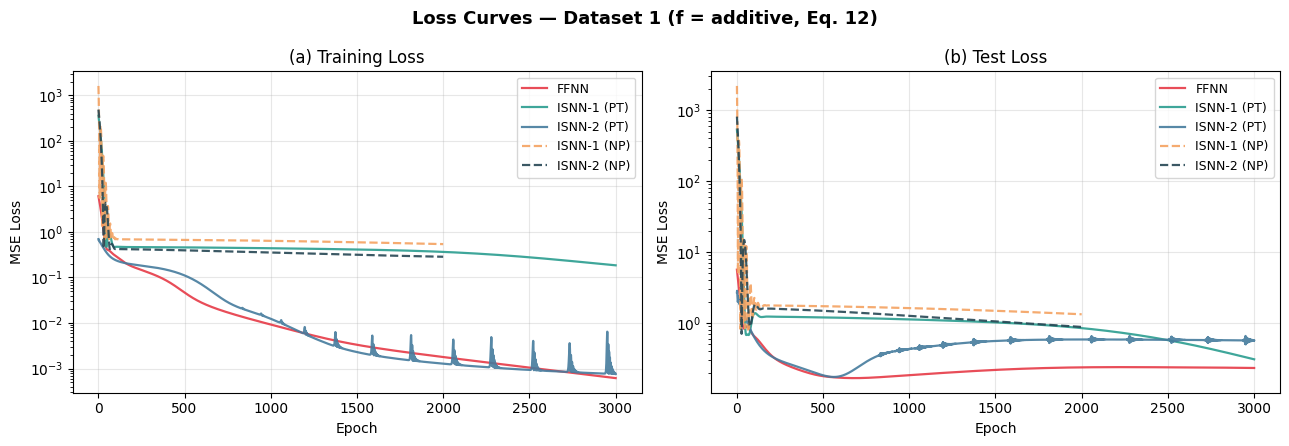

 Behavioral Response, Dataset 1


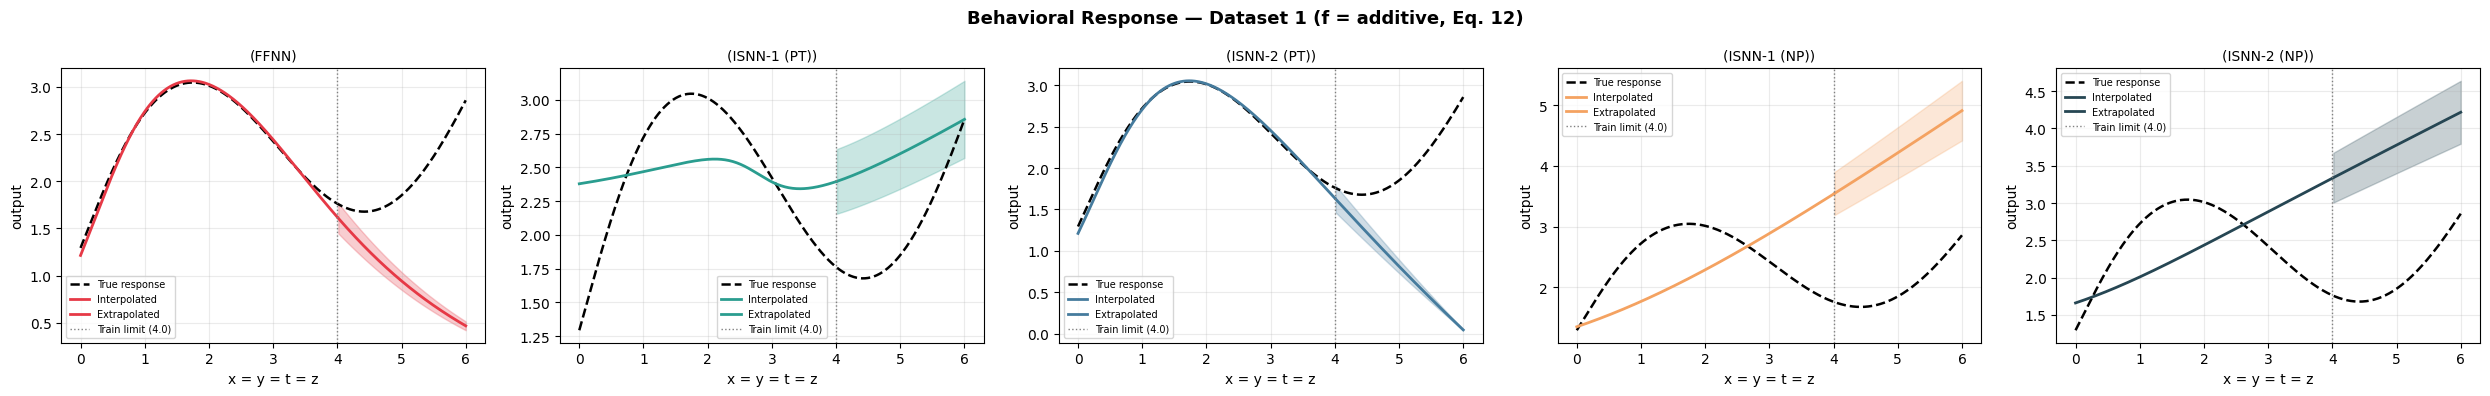

In [58]:
#  FIGURES 3 & 4 — Dataset 1

print(" Loss Curves, Dataset 1 (Eq.12)")
plot_loss_curves(results_ds1, dataset_label='1 (f = additive, Eq. 12)')

print(" Behavioral Response, Dataset 1")
plot_behavioral_response(
    predictors_ds1, fn1,
    train_hi=4.0, test_hi=6.0,
    dataset_label='1 (f = additive, Eq. 12)'
)

 Loss Curves, Dataset 2 (Eq.13)


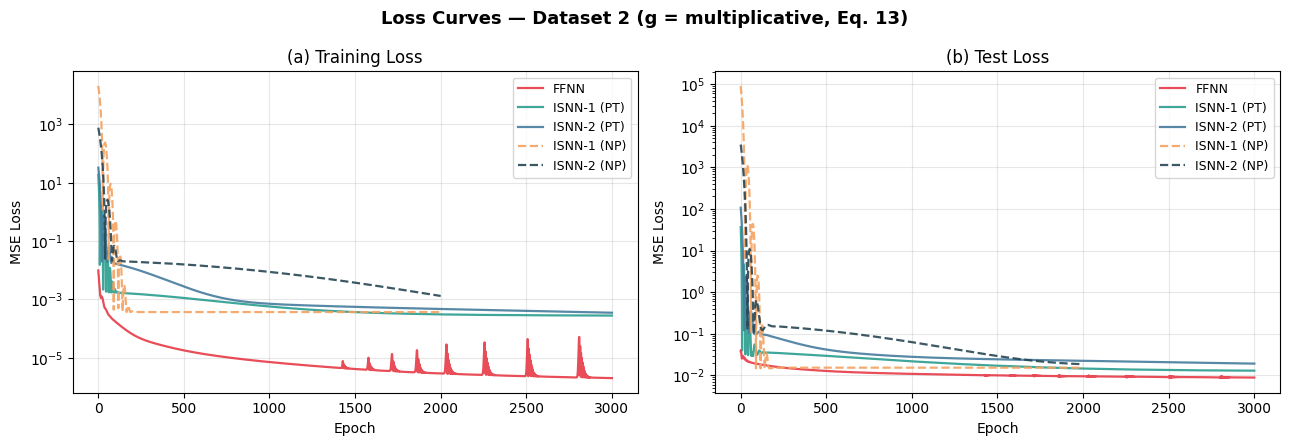

Behavioral Response, Dataset 2


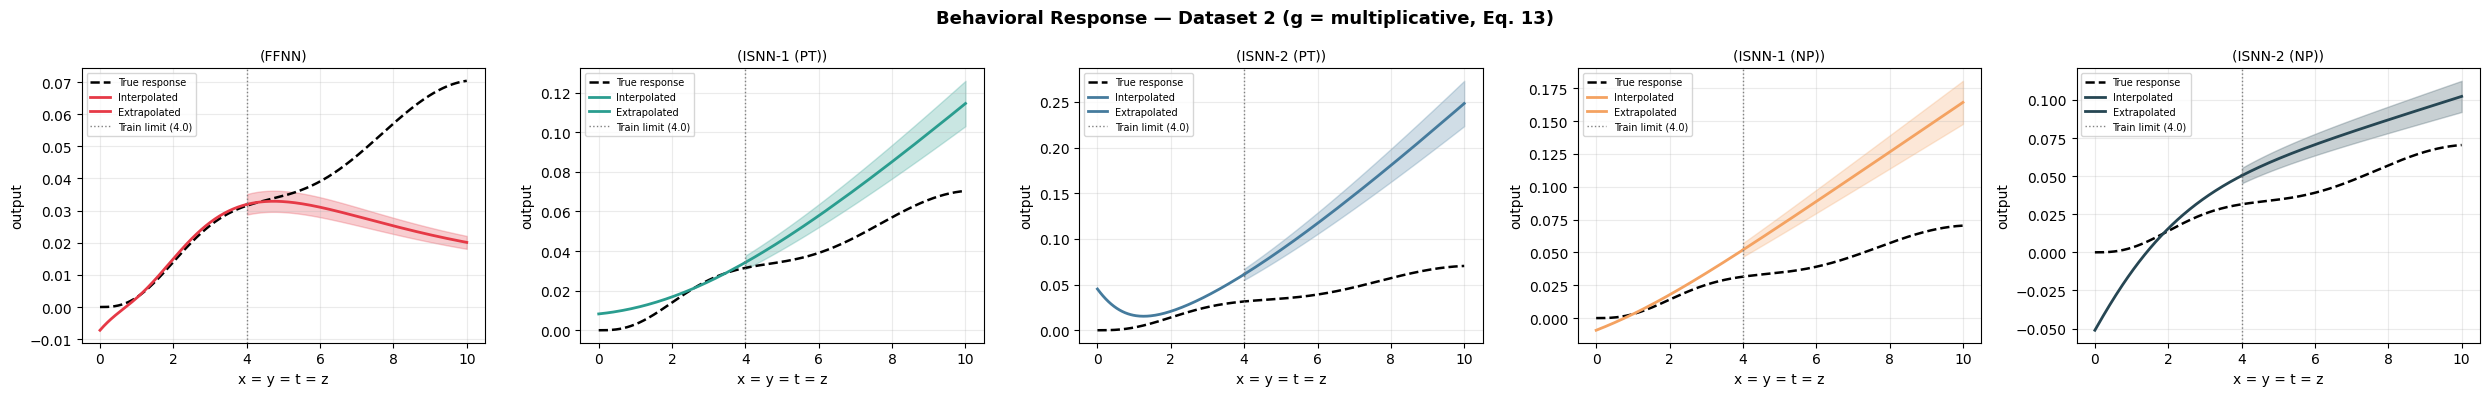

In [57]:
#  FIGURES 5 & 6 — Dataset 2

print(" Loss Curves, Dataset 2 (Eq.13)")
plot_loss_curves(results_ds2, dataset_label='2 (g = multiplicative, Eq. 13)')


print("Behavioral Response, Dataset 2")
plot_behavioral_response(
    predictors_ds2, fn2,
    train_hi=4.0, test_hi=10.0,
    dataset_label='2 (g = multiplicative, Eq. 13)'
)